In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [9]:
df_bio_main = pd.read_csv('working_datasets/cleaned_biometrics_data.csv')
df_demo_main = pd.read_csv('working_datasets/cleaned_demographics_data.csv')
df_enrol_main = pd.read_csv('working_datasets/cleaned_enrolment_data.csv')

In [ ]:
#defining features for enrollment, biometrics and demographics datasets to start isolation forest
enrol_features = df_enrol_main[['state', 'district','pincode','age_0_5','age_5_17','age_18_greater']]
bio_features = df_bio_main[['state', 'district','bio_age_5_17','bio_age_17_']]
demo_features = df_demo_main[['state', 'district','demo_age_5_17','demo_age_17_']]

In [ ]:
#h(x) path length pof instance x
#E[h(x)] average path length across all isolation trees


In [8]:
#define the training parameters 
n_estimators = 100
contamination = 0.01
sample_size = 256

In [11]:
#train isolation forest for enrollment data
isof_enrol = IsolationForest(n_estimators=n_estimators, contamination=contamination, max_samples=sample_size, random_state=42)
isof_enrol.fit(enrol_features)
enrol_features['anomaly_score'] = isof_enrol.decision_function(enrol_features)
enrol_features['anomaly'] = isof_enrol.predict(enrol_features)
anomalies_enrol = enrol_features[enrol_features['anomaly'] == -1]
print(f'Number of anomalies detected in enrollment data: {len(anomalies_enrol)}')


ValueError: could not convert string to float: 'Meghalaya'

In [16]:
# One-hot encode categorical columns
enrol_features_encoded = pd.get_dummies(enrol_features, drop_first=True)

# Train Isolation Forest
isof_enrol = IsolationForest(
    n_estimators=n_estimators,
    contamination=contamination,
    max_samples=sample_size,
    random_state=42
)

isof_enrol.fit(enrol_features_encoded)

# Add anomaly scores back to original dataframe
enrol_features['anomaly_score'] = isof_enrol.decision_function(enrol_features_encoded)
enrol_features['anomaly'] = isof_enrol.predict(enrol_features_encoded)

anomalies_enrol = enrol_features[enrol_features['anomaly'] == -1]

print(f'Number of anomalies detected in enrollment data: {len(anomalies_enrol)}')

C:\Users\hp\AppData\Local\Temp\ipykernel_16764\2062997701.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enrol_features['anomaly_score'] = isof_enrol.decision_function(enrol_features_encoded)


Number of anomalies detected in enrollment data: 9816


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(enrol_features_encoded)

isof_enrol.fit(X_scaled)

enrol_features['anomaly_score'] = isof_enrol.decision_function(X_scaled)
enrol_features['anomaly'] = isof_enrol.predict(X_scaled)

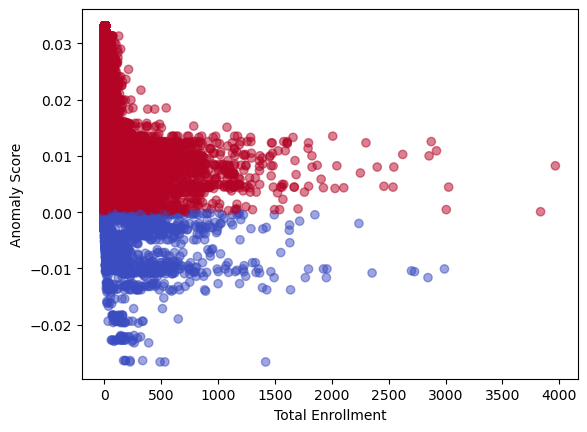

In [26]:
enrol_features['total_enrollment'] = df_enrol_main[['age_0_5', 'age_5_17', 'age_18_greater']].sum(axis=1)

plt.scatter(
    enrol_features['total_enrollment'],
    enrol_features['anomaly_score'],
    c=enrol_features['anomaly'],
    cmap='coolwarm',
    alpha=0.5
)
plt.xlabel("Total Enrollment")
plt.ylabel("Anomaly Score")
plt.show()
